Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Class distribution:
 price_class
Medium    280
High      132
Low        94
Name: count, dtype: int64

=== UNPRUNED TREE ===
Depth          : 12
Leaves         : 51
Train accuracy : 1.0
Test  accuracy : 0.8235294117647058
Test  F1 (wtd) : 0.8240256299079828

=== PRUNED TREE (max_depth=4, min_samples_leaf=5) ===
Depth          : 4
Leaves  

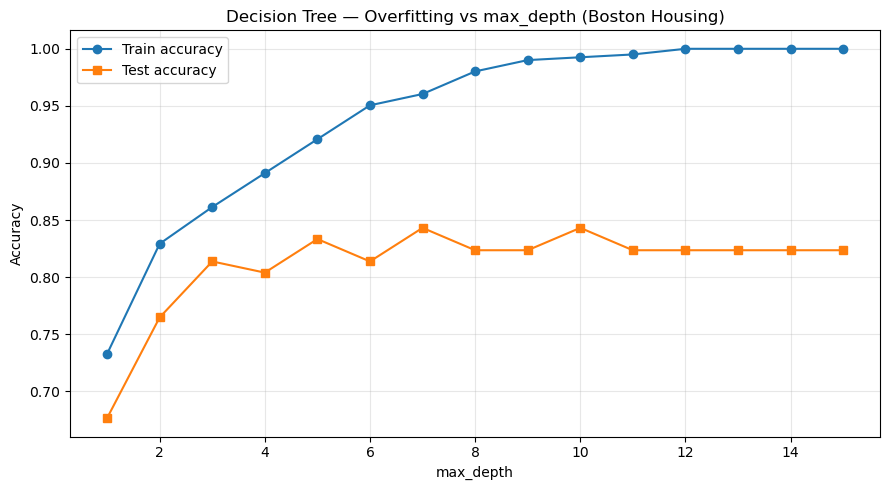


=== Classification Report — Pruned Tree ===
              precision    recall  f1-score   support

         Low       0.76      0.84      0.80        19
      Medium       0.80      0.77      0.78        56
        High       0.70      0.70      0.70        27

    accuracy                           0.76       102
   macro avg       0.75      0.77      0.76       102
weighted avg       0.77      0.76      0.76       102



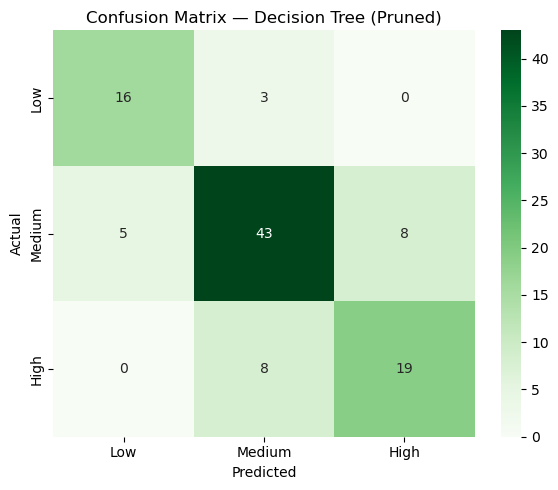

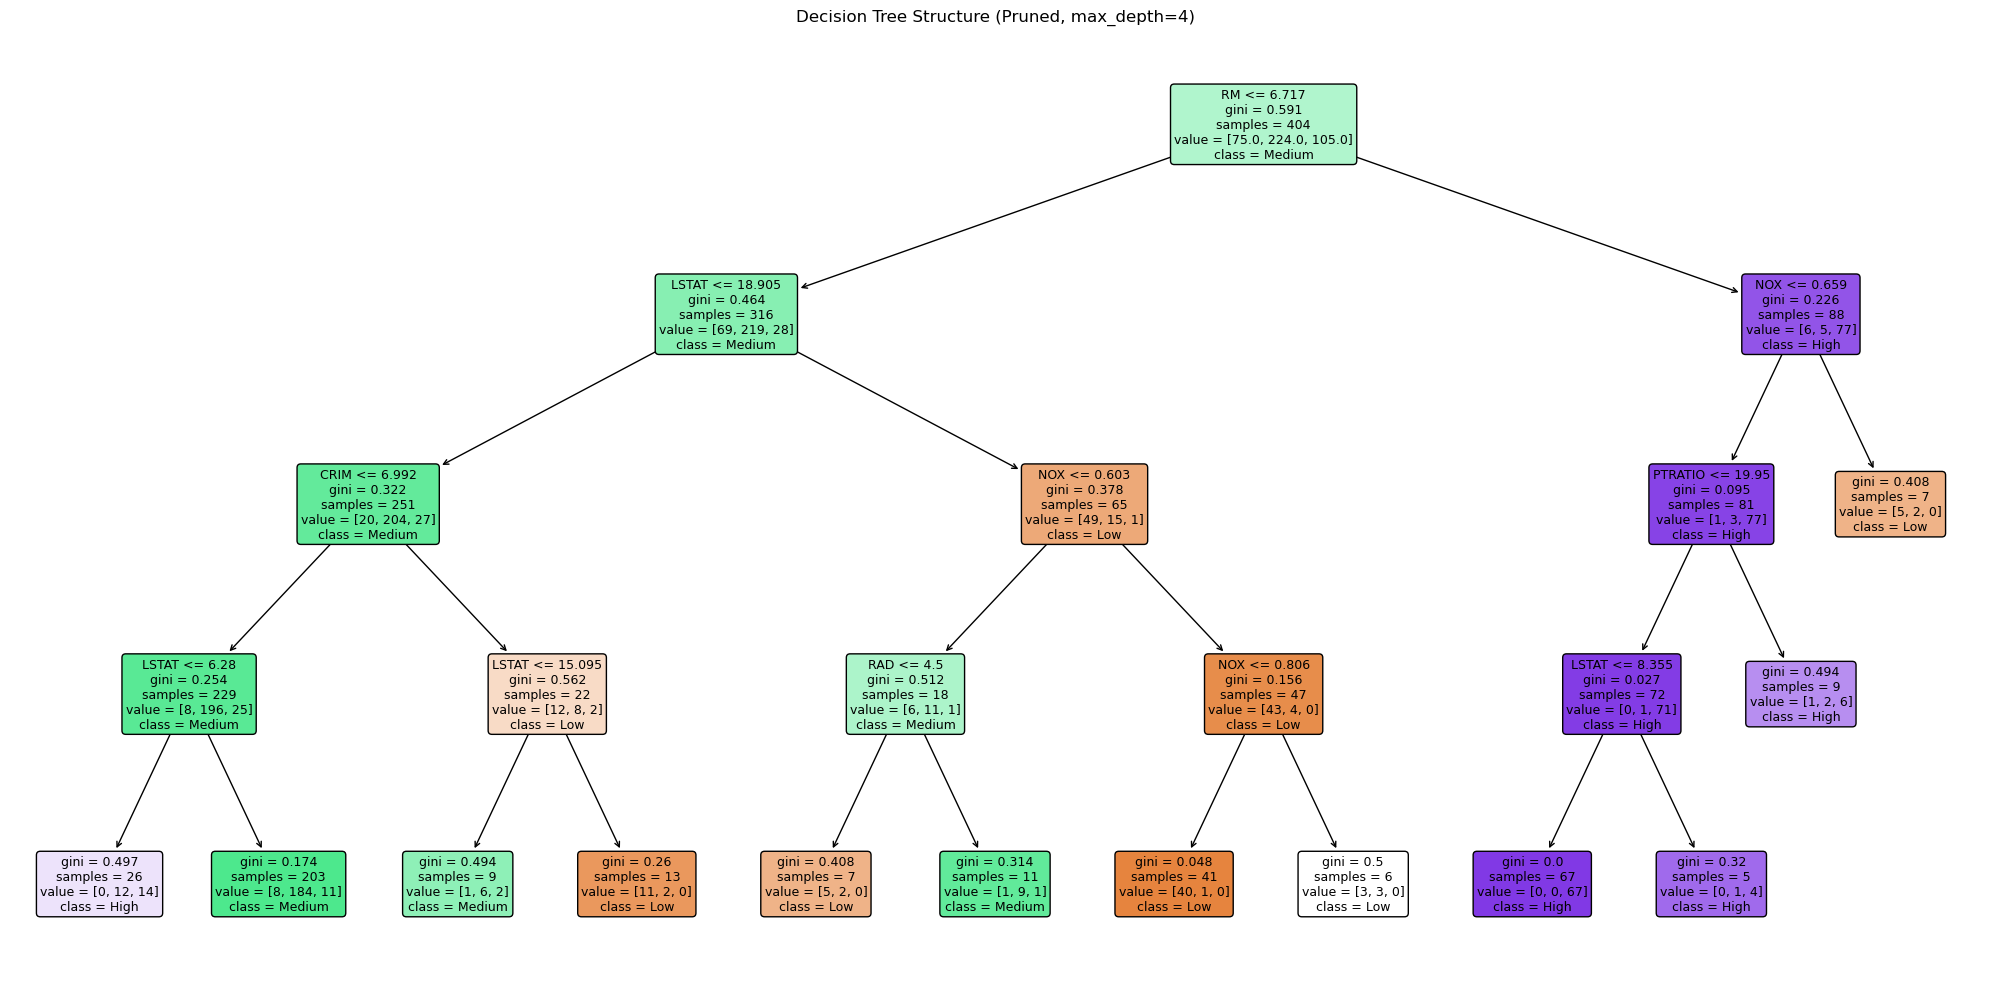

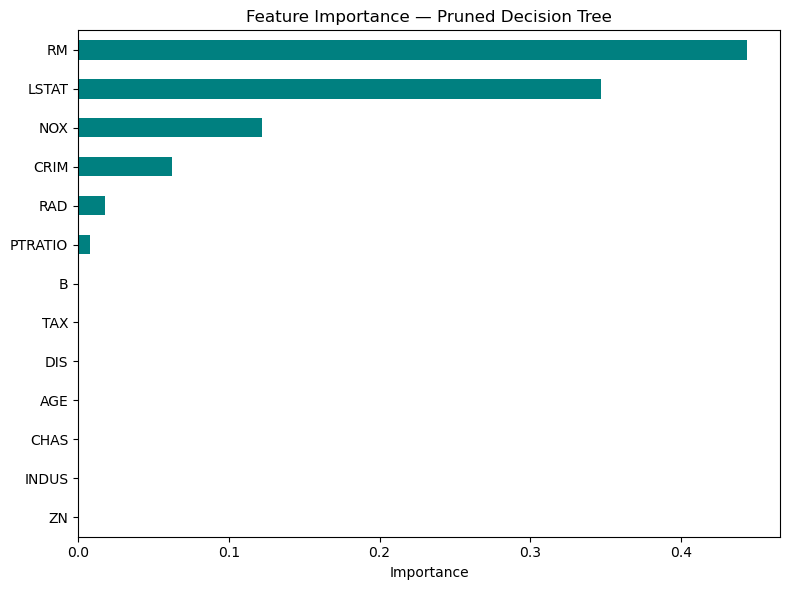

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

# ---------------------------------------------------------
# 1. Load the Boston Housing dataset (no header in the file)
# ---------------------------------------------------------
path = r"C:\Users\250 G7\Desktop\CodeVeda Intern\Dataset\4) house Prediction Data Set.csv"

df = pd.read_csv(path, header=None, sep=r"\s+", engine="python")
df.columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

print("Shape:", df.shape)
print(df.head())

# ---------------------------------------------------------
# 2. Bin continuous target MEDV into 3 classes
# ---------------------------------------------------------
def bin_medv(v):
    if v < 15:
        return "Low"
    elif v < 25:
        return "Medium"
    else:
        return "High"

df["price_class"] = df["MEDV"].apply(bin_medv)
print("\nClass distribution:\n", df["price_class"].value_counts())

class_order = ["Low", "Medium", "High"]
df["price_class_encoded"] = df["price_class"].map(
    {c: i for i, c in enumerate(class_order)}
)

# ---------------------------------------------------------
# 3. Features + target
# ---------------------------------------------------------
feature_cols = [c for c in df.columns if c not in
                ["MEDV", "price_class", "price_class_encoded"]]
X = df[feature_cols]
y = df["price_class_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 4. Unpruned tree (baseline — likely overfit)
# ---------------------------------------------------------
tree_unpruned = DecisionTreeClassifier(random_state=42)
tree_unpruned.fit(X_train, y_train)
y_pred_un = tree_unpruned.predict(X_test)

print("\n=== UNPRUNED TREE ===")
print("Depth          :", tree_unpruned.get_depth())
print("Leaves         :", tree_unpruned.get_n_leaves())
print("Train accuracy :", accuracy_score(y_train, tree_unpruned.predict(X_train)))
print("Test  accuracy :", accuracy_score(y_test, y_pred_un))
print("Test  F1 (wtd) :", f1_score(y_test, y_pred_un, average="weighted"))

# ---------------------------------------------------------
# 5. Pruned tree (limit depth + min samples)
# ---------------------------------------------------------
tree_pruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
tree_pruned.fit(X_train, y_train)
y_pred_pr = tree_pruned.predict(X_test)

print("\n=== PRUNED TREE (max_depth=4, min_samples_leaf=5) ===")
print("Depth          :", tree_pruned.get_depth())
print("Leaves         :", tree_pruned.get_n_leaves())
print("Train accuracy :", accuracy_score(y_train, tree_pruned.predict(X_train)))
print("Test  accuracy :", accuracy_score(y_test, y_pred_pr))
print("Test  F1 (wtd) :", f1_score(y_test, y_pred_pr, average="weighted"))

# ---------------------------------------------------------
# 6. Cross-validated comparison over max_depth
# ---------------------------------------------------------
depths = range(1, 16)
train_scores = []
test_scores = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, test_scores, marker="s", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree — Overfitting vs max_depth (Boston Housing)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. Full classification report (pruned)
# ---------------------------------------------------------
print("\n=== Classification Report — Pruned Tree ===")
print(classification_report(
    y_test, y_pred_pr, target_names=class_order
))

# ---------------------------------------------------------
# 8. Confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_pr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_order, yticklabels=class_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree (Pruned)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Visualize the tree (pruned version)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))
plot_tree(
    tree_pruned,
    feature_names=feature_cols,
    class_names=class_order,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Structure (Pruned, max_depth=4)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. Feature importance
# ---------------------------------------------------------
importances = pd.Series(
    tree_pruned.feature_importances_, index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importance — Pruned Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()